# S6E7: Predicting Student Health Risk 

Public LB **0.94960** üreten akış: V2-Core features + 3-fold LightGBM + class multipliers.

## 1. Setup

In [1]:
from pathlib import Path
import gc
import platform
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
ID_COL = "id"
TARGET = "health_condition"
CLASSES = ["at-risk", "fit", "unhealthy"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASSES)}
NUM_COLS = [
    "sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
    "step_count", "exercise_duration", "water_intake",
]
CAT_COLS = [
    "diet_type", "stress_level", "sleep_quality", "physical_activity_level",
    "smoking_alcohol", "gender",
]
RATIO_DEFS = {
    "calorie_per_step": ("calorie_expenditure", "step_count"),
    "calorie_per_exercise_min": ("calorie_expenditure", "exercise_duration"),
    "step_per_exercise_min": ("step_count", "exercise_duration"),
    "water_per_bmi": ("water_intake", "bmi"),
    "exercise_per_bmi": ("exercise_duration", "bmi"),
    "steps_per_sleep_hour": ("step_count", "sleep_duration"),
}
RATIO_COLS = list(RATIO_DEFS)
INTERACTION_DEFS = {
    "stress_sleep_quality": ("stress_level", "sleep_quality"),
    "activity_diet": ("physical_activity_level", "diet_type"),
    "smoking_activity": ("smoking_alcohol", "physical_activity_level"),
}

print({
    "python": platform.python_version(),
    "lightgbm": lgb.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
})

{'python': '3.12.13', 'lightgbm': '4.6.0', 'numpy': '2.0.2', 'pandas': '2.3.3'}


## 2. Data Loading

In [2]:
def locate_data():
    roots = [Path("/kaggle/input"), Path("../input"), Path("data/playground-series-s6e7"), Path(".")]
    for root in roots:
        if not root.exists():
            continue
        train_files = list(root.rglob("train.csv"))
        for train_path in train_files:
            test_path = train_path.with_name("test.csv")
            sample_path = train_path.with_name("sample_submission.csv")
            if test_path.exists() and sample_path.exists():
                return train_path, test_path, sample_path
    raise FileNotFoundError("train.csv, test.csv and sample_submission.csv were not found")

TRAIN_PATH, TEST_PATH, SAMPLE_PATH = locate_data()
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("Data directory:", TRAIN_PATH.parent)
print("Train/Test:", train.shape, test.shape)
display(train.head())

Data directory: /kaggle/input/competitions/playground-series-s6e7
Train/Test: (690088, 15) (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [3]:
assert TARGET in train and TARGET not in test
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert set(train[TARGET].unique()) == set(CLASSES)
assert list(sample_submission.columns) == [ID_COL, TARGET]

schema = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_train": train.isna().sum(),
    "missing_test": test.isna().sum().reindex(train.columns),
    "nunique": train.nunique(dropna=False),
})
display(schema)
print("Duplicate train rows:", train.duplicated().sum())

,dtype,missing_train,missing_test,nunique
id,int64,0,0.0,690088
health_condition,object,0,NaN,3
sleep_duration,float64,75999,32571.0,702
heart_rate,float64,7833,3357.0,538
bmi,float64,13898,5956.0,1597
calorie_expenditure,float64,52853,22652.0,2102
step_count,float64,13916,5964.0,12808
exercise_duration,float64,6901,2958.0,857
water_intake,float64,43477,18633.0,401
diet_type,object,6901,2958.0,4


Duplicate train rows: 0


### 2.1 Data Contract and Leakage Checks

In [4]:
expected_features = set(NUM_COLS + CAT_COLS)
assert expected_features.issubset(train.columns)
assert expected_features.issubset(test.columns)
assert set(train.columns) - {TARGET} == set(test.columns)
assert not train[ID_COL].isin(test[ID_COL]).any(), "Train/test IDs overlap"

contract = pd.DataFrame({
    "train_dtype": train.dtypes.astype(str),
    "test_dtype": test.dtypes.astype(str).reindex(train.columns),
    "train_unique": train.nunique(dropna=False),
    "test_unique": test.nunique(dropna=False).reindex(train.columns),
})
display(contract)
print("Leakage checks passed: schemas align and IDs do not overlap.")

,train_dtype,test_dtype,train_unique,test_unique
id,int64,int64,690088,295753.0
health_condition,object,NaN,3,NaN
sleep_duration,float64,float64,702,693.0
heart_rate,float64,float64,538,527.0
bmi,float64,float64,1597,1549.0
calorie_expenditure,float64,float64,2102,2069.0
step_count,float64,float64,12808,12197.0
exercise_duration,float64,float64,857,818.0
water_intake,float64,float64,401,393.0
diet_type,object,object,4,4.0


Leakage checks passed: schemas align and IDs do not overlap.


## 3. Exploratory Data Analysis

### 3.1 Target and Missing Values

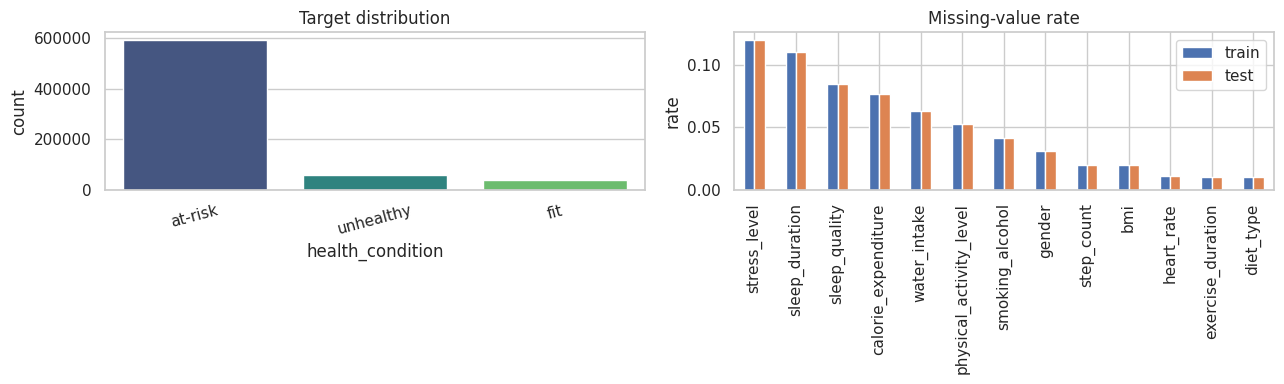

,percent
health_condition,
at-risk,85.867
unhealthy,8.365
fit,5.768


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = train[TARGET].value_counts().index
sns.countplot(data=train, x=TARGET, order=order, ax=axes[0], palette="viridis")
axes[0].set_title("Target distribution")
axes[0].tick_params(axis="x", rotation=15)

missing = pd.DataFrame({"train": train.isna().mean(), "test": test.isna().mean()}).fillna(0)
missing = missing.loc[missing.max(axis=1).gt(0)].sort_values("train", ascending=False)
missing.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Missing-value rate")
axes[1].set_ylabel("rate")
plt.tight_layout()
plt.show()

display((train[TARGET].value_counts(normalize=True).mul(100).rename("percent").to_frame()).round(3))

### 3.2 Missingness–Target Signal

,feature,is_missing,rows,rate_at-risk,rate_fit,rate_unhealthy
11,exercise_duration,True,6901,85.089%,6.043%,8.868%
13,water_intake,True,43477,85.510%,5.805%,8.685%
25,gender,True,21373,85.828%,5.568%,8.604%
23,smoking_alcohol,True,28582,85.680%,5.766%,8.554%
7,calorie_expenditure,True,52853,85.804%,5.799%,8.397%
17,stress_level,True,82811,85.894%,5.747%,8.359%
21,physical_activity_level,True,36621,85.942%,5.721%,8.337%
1,sleep_duration,True,75999,85.933%,5.732%,8.336%
19,sleep_quality,True,58331,85.963%,5.819%,8.219%
15,diet_type,True,6901,86.756%,5.086%,8.158%


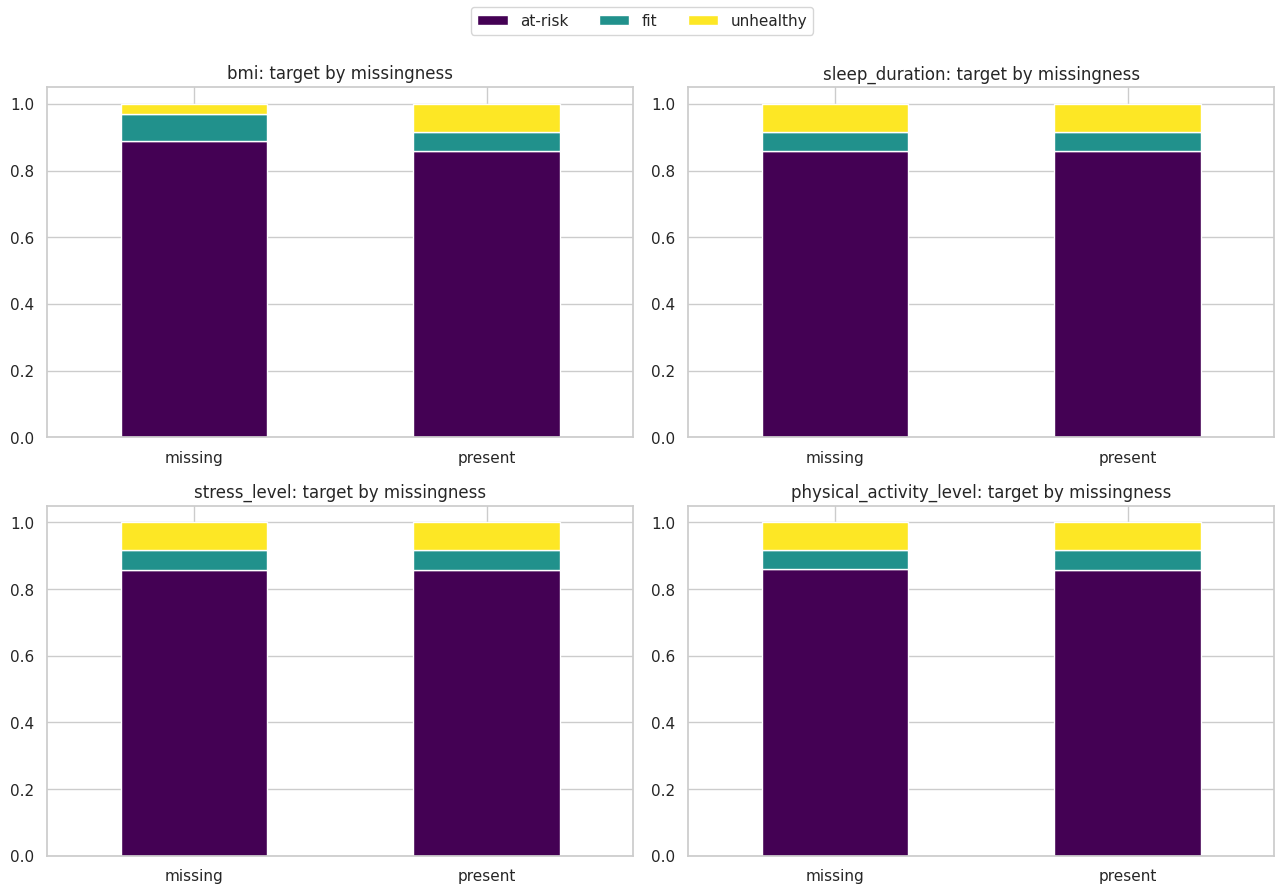

In [6]:
missing_target_rows = []
for col in NUM_COLS + CAT_COLS:
    for is_missing, group in train.groupby(train[col].isna(), observed=True):
        rates = group[TARGET].value_counts(normalize=True).reindex(CLASSES, fill_value=0)
        missing_target_rows.append({
            "feature": col, "is_missing": bool(is_missing), "rows": len(group),
            **{f"rate_{label}": rates[label] for label in CLASSES},
        })
missing_target = pd.DataFrame(missing_target_rows)
missing_only = missing_target.query("is_missing").sort_values("rate_unhealthy", ascending=False)
display(missing_only.style.format({c: "{:.3%}" for c in missing_only if c.startswith("rate_")}))

plot_cols = ["bmi", "sleep_duration", "stress_level", "physical_activity_level"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, plot_cols):
    table = pd.crosstab(train[col].isna().map({False: "present", True: "missing"}), train[TARGET], normalize="index")
    table[CLASSES].plot(kind="bar", stacked=True, ax=ax, colormap="viridis", legend=False)
    ax.set_title(f"{col}: target by missingness")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### 3.3 Train–Test Distribution Shift

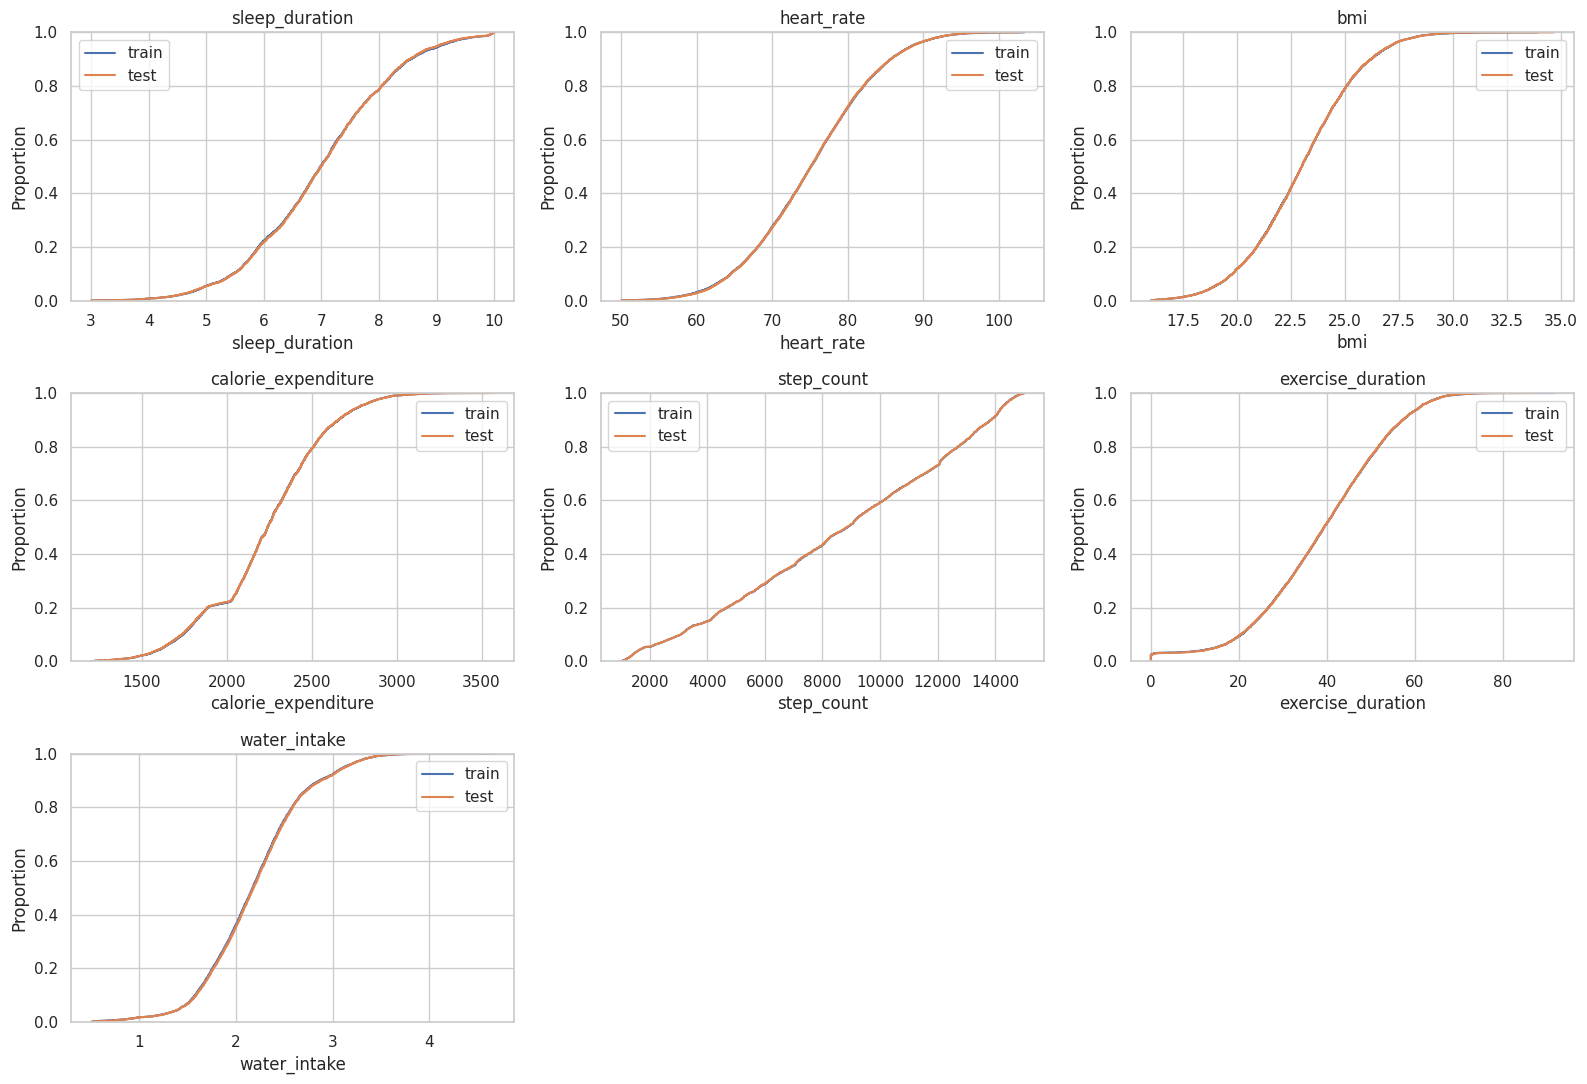

,feature,total_variation_distance
5,gender,0.0331
3,physical_activity_level,0.0086
4,smoking_alcohol,0.0020
2,sleep_quality,0.0013
1,stress_level,0.0012
0,diet_type,0.0008


In [7]:
eda_train = train.sample(min(50_000, len(train)), random_state=SEED)
eda_test = test.sample(min(50_000, len(test)), random_state=SEED)
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flat, NUM_COLS):
    sns.ecdfplot(data=eda_train, x=col, label="train", ax=ax)
    sns.ecdfplot(data=eda_test, x=col, label="test", ax=ax)
    ax.set_title(col)
    ax.legend()
for ax in axes.flat[len(NUM_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

shift_rows = []
for col in CAT_COLS:
    tr = train[col].fillna("missing").value_counts(normalize=True)
    te = test[col].fillna("missing").value_counts(normalize=True)
    levels = tr.index.union(te.index)
    tvd = 0.5 * (tr.reindex(levels, fill_value=0) - te.reindex(levels, fill_value=0)).abs().sum()
    shift_rows.append({"feature": col, "total_variation_distance": tvd})
shift_table = pd.DataFrame(shift_rows).sort_values("total_variation_distance", ascending=False)
display(shift_table.style.format({"total_variation_distance": "{:.4f}"}))

### 3.4 Numerical Feature Distributions

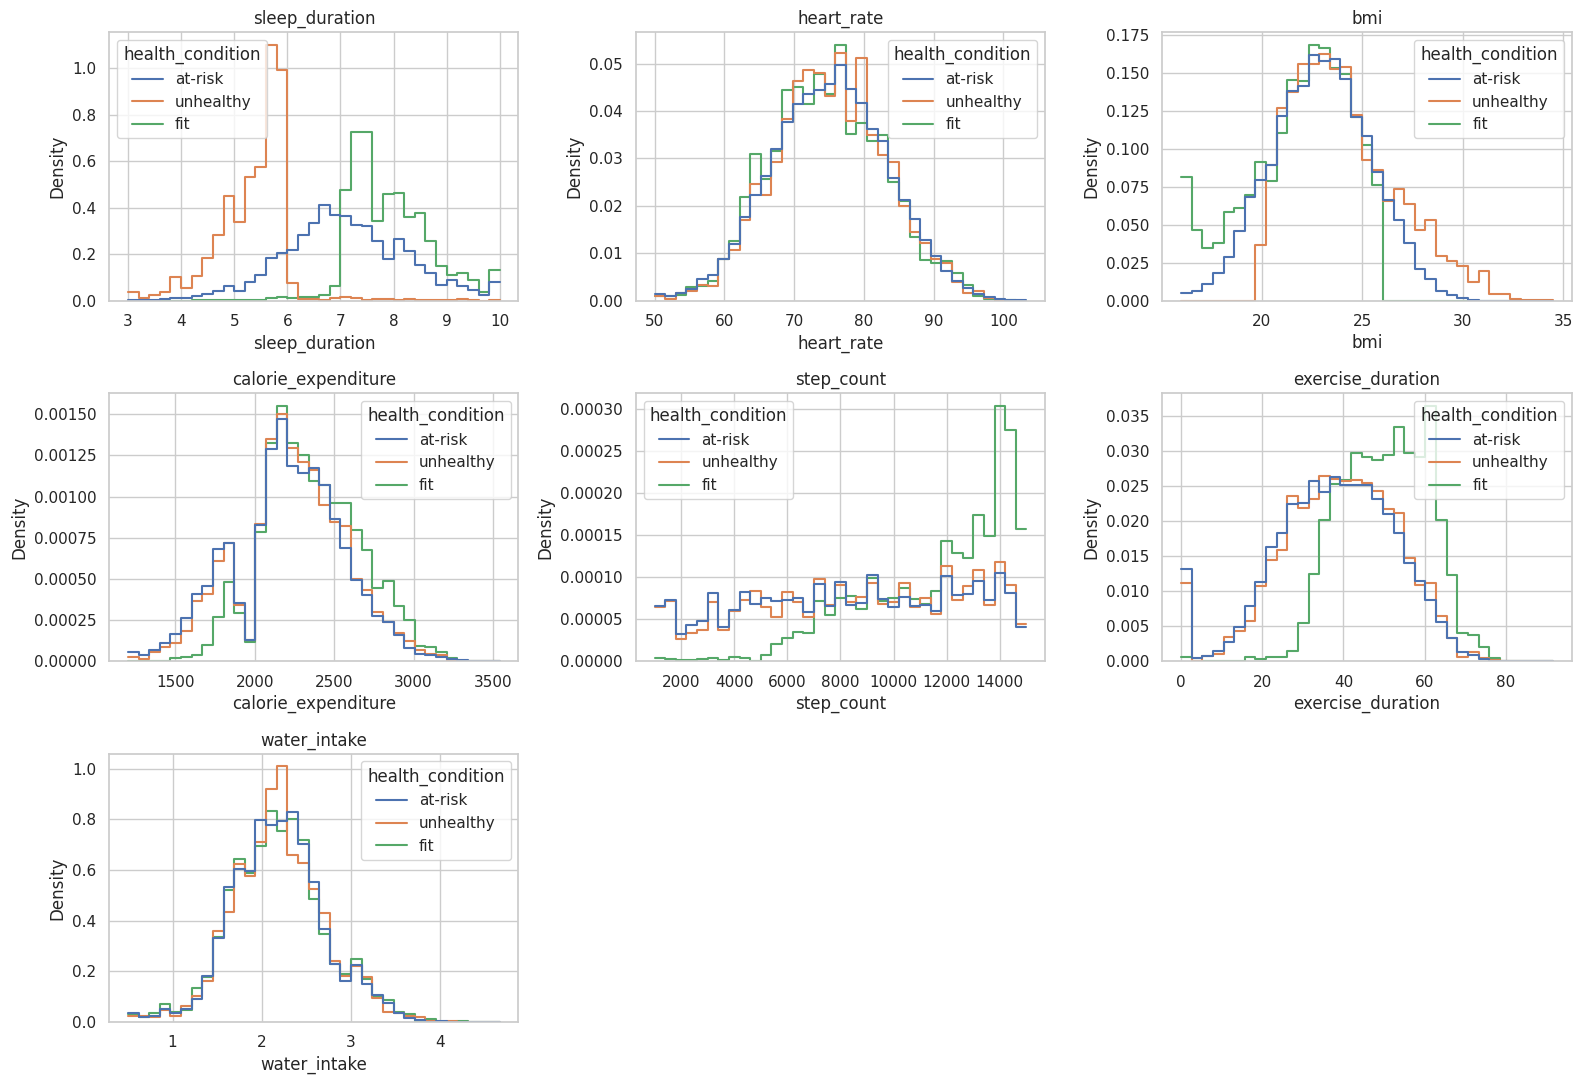

In [8]:
plot_train = train.sample(min(60_000, len(train)), random_state=SEED)
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flat, NUM_COLS):
    sns.histplot(data=plot_train, x=col, hue=TARGET, stat="density", common_norm=False,
                 element="step", fill=False, bins=35, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(NUM_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3.5 Categorical Feature Distributions

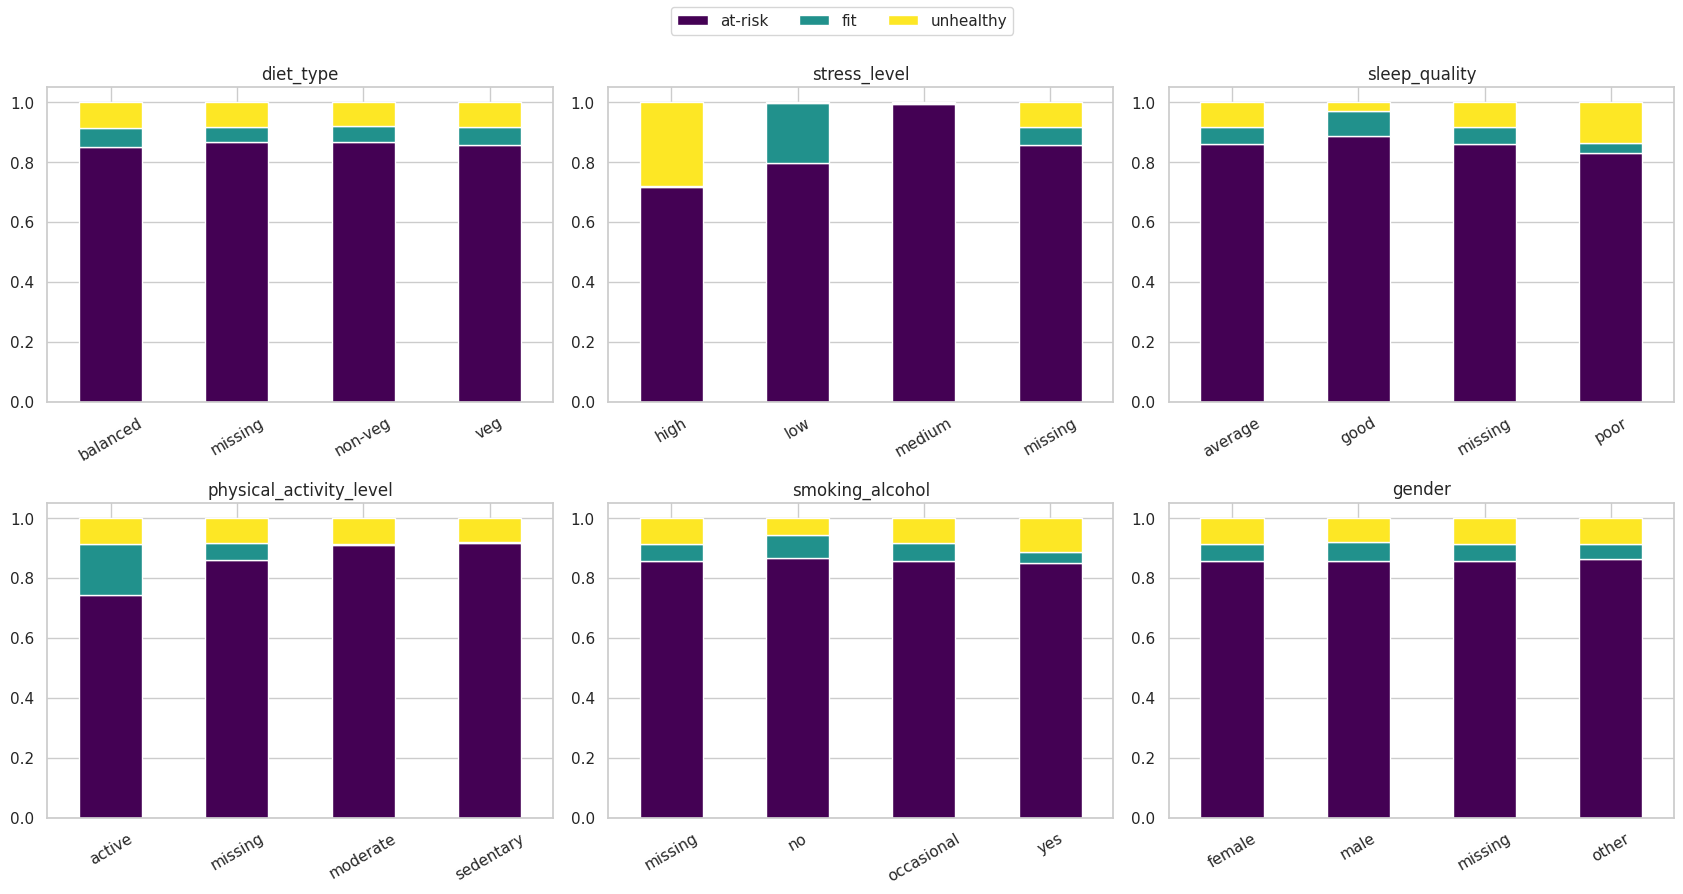

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flat, CAT_COLS):
    rates = pd.crosstab(train[col].fillna("missing"), train[TARGET], normalize="index")
    rates[CLASSES].plot(kind="bar", stacked=True, ax=ax, colormap="viridis", legend=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### 3.6 Correlation Analysis

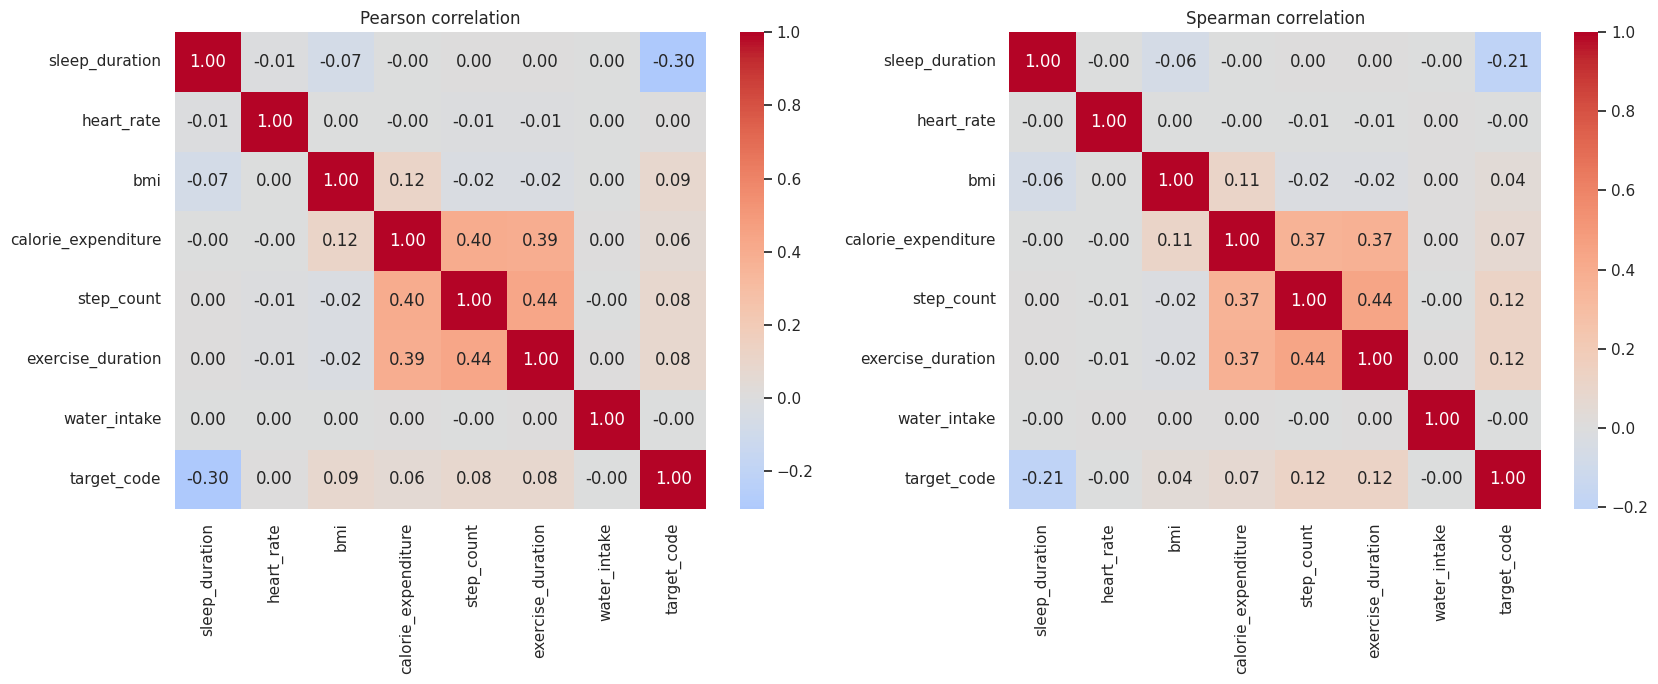

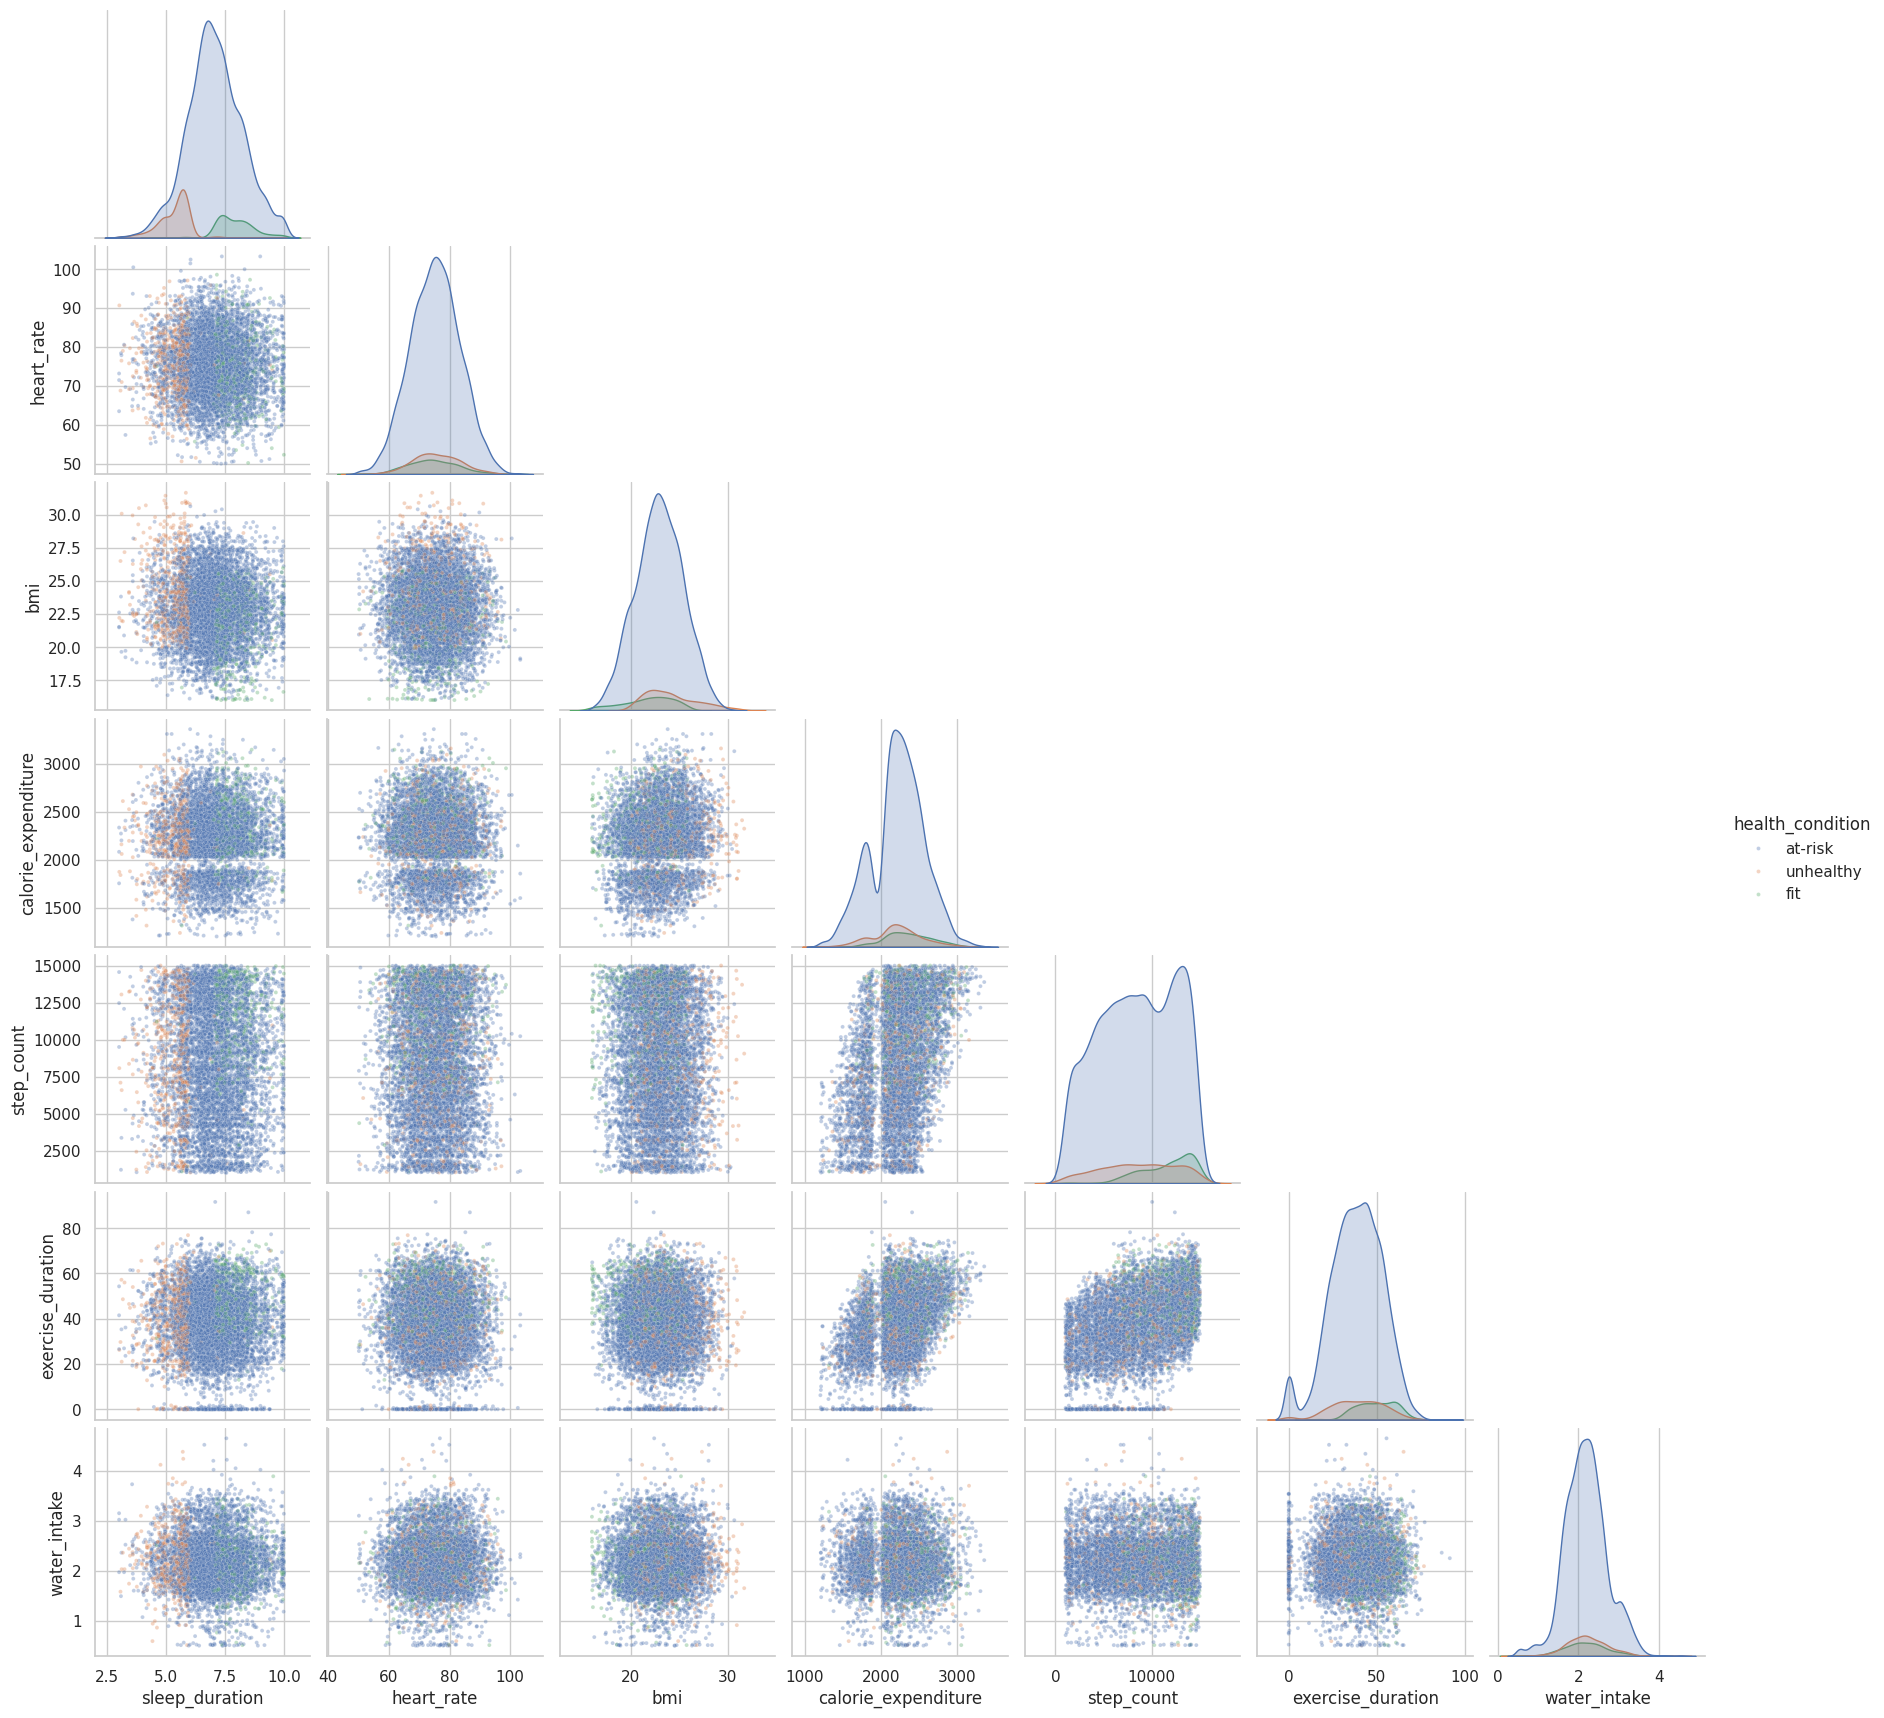

In [10]:
corr_frame = train[NUM_COLS].copy()
corr_frame["target_code"] = train[TARGET].map(CLASS_TO_ID)
pearson = corr_frame.corr(method="pearson")
spearman = corr_frame.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Pearson correlation")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

pair_sample = train.sample(min(8_000, len(train)), random_state=SEED)
sns.pairplot(pair_sample, vars=NUM_COLS, hue=TARGET, corner=True, plot_kws={"s": 8, "alpha": 0.35})
plt.show()

## 4. Outlier Analysis

,0.005,0.25,0.5,0.75,0.995,outside_0.5_99.5_pct
sleep_duration,3.85,6.16,6.99,7.81,9.96,0.844
heart_rate,54.00,69.40,75.10,80.70,95.30,0.970
bmi,16.55,21.32,22.99,24.66,29.40,0.967
calorie_expenditure,1312.00,2053.00,2241.00,2456.00,3093.00,0.909
step_count,1136.00,5389.00,8856.00,12114.00,14863.00,0.963
exercise_duration,0.00,29.20,39.40,49.40,70.10,0.488
water_intake,0.66,1.84,2.17,2.50,3.56,0.892


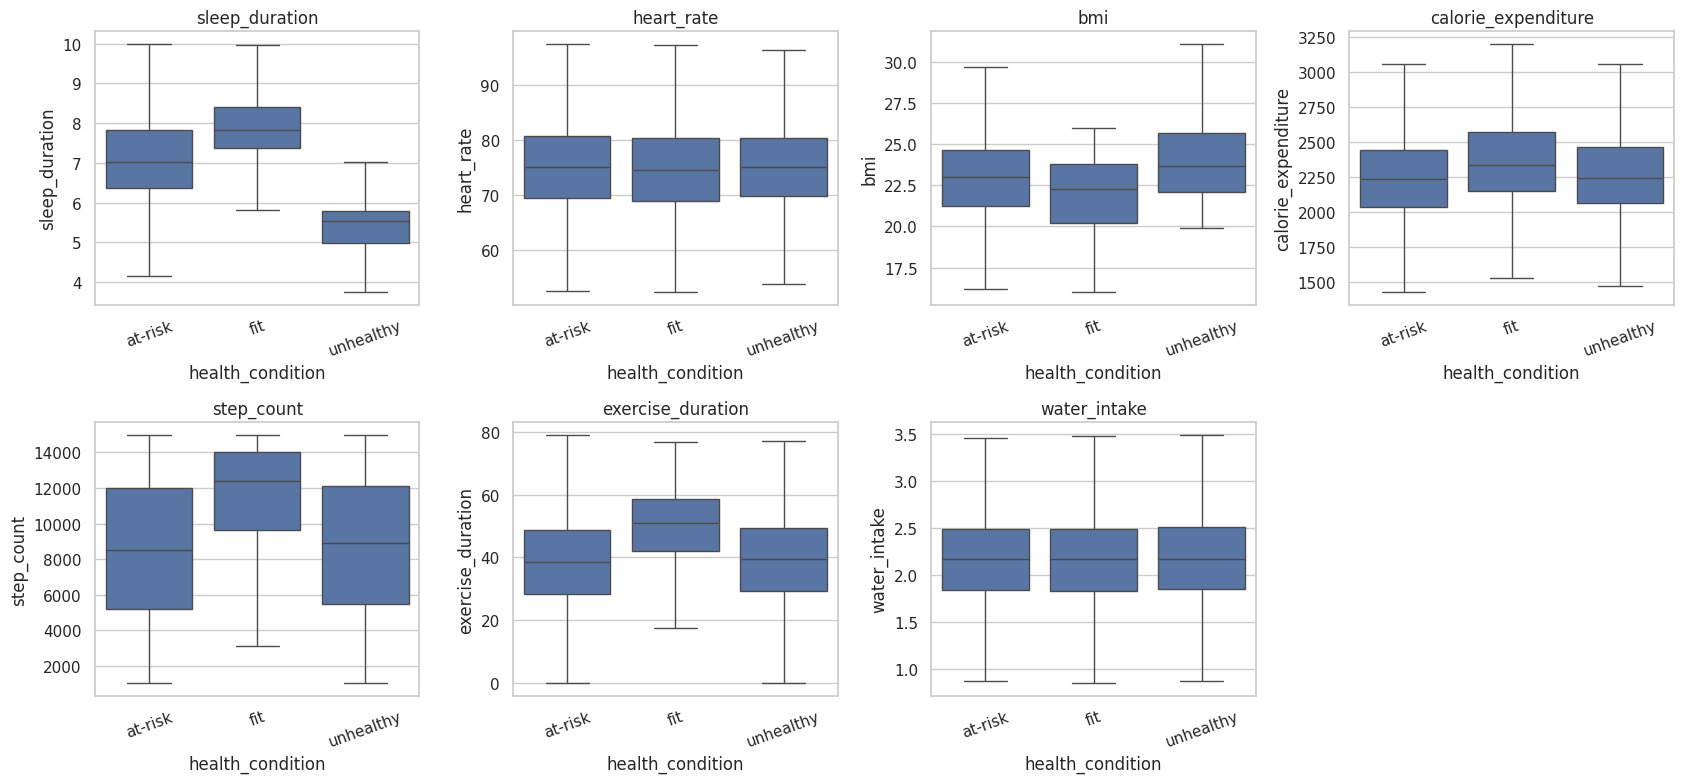

In [11]:
quantiles = train[NUM_COLS].quantile([0.005, 0.25, 0.5, 0.75, 0.995]).T
quantiles["outside_0.5_99.5_pct"] = [
    ((train[c] < quantiles.loc[c, 0.005]) | (train[c] > quantiles.loc[c, 0.995])).mean() * 100
    for c in NUM_COLS
]
display(quantiles.round(3))

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, col in zip(axes.flat, NUM_COLS):
    sns.boxplot(data=plot_train, x=TARGET, y=col, order=CLASSES, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)
for ax in axes.flat[len(NUM_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 4.1 Clipping and Removal Impact (Analysis Only)

,feature,lower_0.5%,upper_99.5%,rows_flagged,rows_flagged_pct,raw_std,clipped_std
0,sleep_duration,3.850000,9.960000,5821,0.844%,1.215,1.210
1,heart_rate,54.000000,95.300000,6691,0.970%,8.175,8.124
2,bmi,16.550000,29.400000,6674,0.967%,2.482,2.464
3,calorie_expenditure,1312.000000,3093.000000,6274,0.909%,347.532,345.387
4,step_count,1136.000000,14863.000000,6643,0.963%,3929.400,3928.154
5,exercise_duration,0.000000,70.100000,3370,0.488%,14.742,14.708
6,water_intake,0.660000,3.560000,6157,0.892%,0.518,0.514


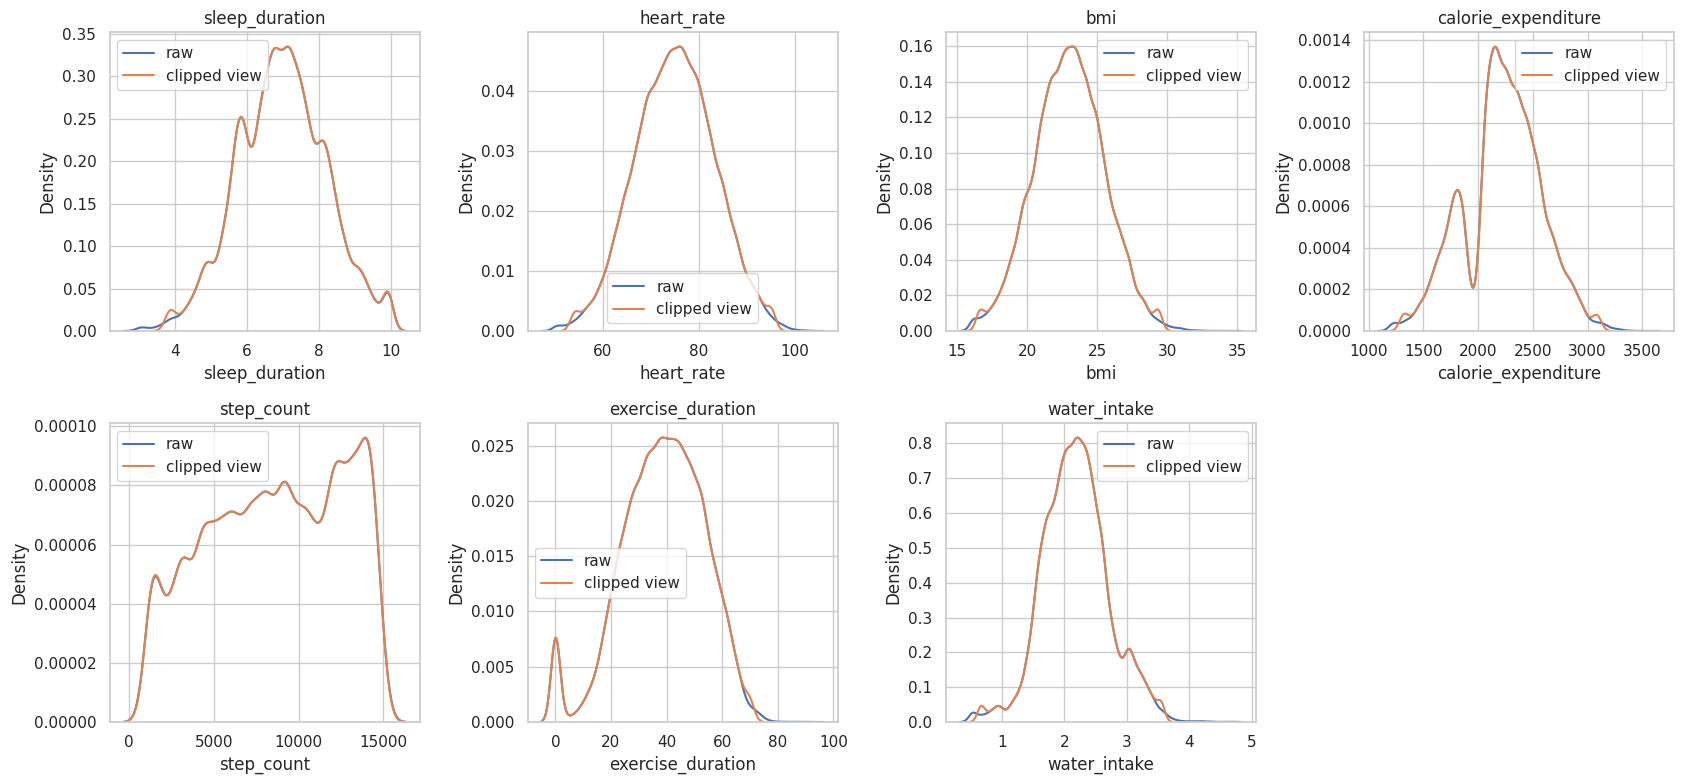

In [12]:
outlier_impact = []
for col in NUM_COLS:
    low, high = train[col].quantile([0.005, 0.995])
    outside = train[col].notna() & ((train[col] < low) | (train[col] > high))
    clipped = train[col].clip(low, high)
    outlier_impact.append({
        "feature": col, "lower_0.5%": low, "upper_99.5%": high,
        "rows_flagged": int(outside.sum()), "rows_flagged_pct": outside.mean(),
        "raw_std": train[col].std(), "clipped_std": clipped.std(),
    })
outlier_impact = pd.DataFrame(outlier_impact)
display(outlier_impact.style.format({"rows_flagged_pct": "{:.3%}", "raw_std": "{:.3f}", "clipped_std": "{:.3f}"}))

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, col in zip(axes.flat, NUM_COLS):
    low, high = train[col].quantile([0.005, 0.995])
    sample = plot_train[col].dropna()
    sns.kdeplot(sample, label="raw", ax=ax)
    sns.kdeplot(sample.clip(low, high), label="clipped view", ax=ax)
    ax.set_title(col)
    ax.legend()
for ax in axes.flat[len(NUM_COLS):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

# E002 keeps informative extremes: no row removal and no clipping is applied to model features.

## 5. Fold-Safe Feature Engineering

In [13]:
class V2CorePreprocessor:
    def fit(self, frame):
        self.medians_ = frame[NUM_COLS].median()
        prepared = self._base(frame)
        outlier_sources = NUM_COLS + RATIO_COLS
        self.bounds_ = {
            col: tuple(prepared[col].quantile([0.005, 0.995])) for col in outlier_sources
        }
        flagged = self._flags(prepared)
        candidates = [f"{col}_outlier_{side}" for col in outlier_sources for side in ("low", "high")]
        self.active_flags_ = [c for c in candidates if flagged[c].nunique(dropna=False) > 1]

        categorical = CAT_COLS + list(INTERACTION_DEFS)
        self.category_levels_ = {
            col: sorted(flagged[col].astype(str).unique().tolist()) + ["__UNKNOWN__"]
            for col in categorical
        }
        transformed = self._finish(flagged)
        self.feature_names_ = transformed.columns.tolist()
        return self

    def transform(self, frame):
        flagged = self._flags(self._base(frame))
        return self._finish(flagged).reindex(columns=self.feature_names_)

    def fit_transform(self, frame):
        return self.fit(frame).transform(frame)

    def _base(self, frame):
        result = frame[NUM_COLS + CAT_COLS].copy()
        raw_missing = result.isna()
        for col in NUM_COLS + CAT_COLS:
            result[f"{col}_is_missing"] = raw_missing[col].astype("int8")
        result["missing_count"] = raw_missing.sum(axis=1).astype("int16")
        result[NUM_COLS] = result[NUM_COLS].fillna(self.medians_)
        result[CAT_COLS] = result[CAT_COLS].fillna("missing")

        for output, (numerator, denominator) in RATIO_DEFS.items():
            result[output] = result[numerator].div(result[denominator].add(1)).replace([np.inf, -np.inf], np.nan)
        for output, (left, right) in INTERACTION_DEFS.items():
            result[output] = result[left].astype(str) + "__" + result[right].astype(str)
        return result

    def _flags(self, result):
        result = result.copy()
        for col, (low, high) in self.bounds_.items():
            result[f"{col}_outlier_low"] = (result[col] < low).astype("int8")
            result[f"{col}_outlier_high"] = (result[col] > high).astype("int8")
        return result

    def _finish(self, result):
        result = result.copy()
        result["outlier_count"] = result[self.active_flags_].sum(axis=1).astype("int16")
        keep = (NUM_COLS + CAT_COLS +
                [f"{c}_is_missing" for c in NUM_COLS + CAT_COLS] +
                ["missing_count"] + RATIO_COLS + list(INTERACTION_DEFS) +
                self.active_flags_ + ["outlier_count"])
        result = result[keep]
        for col, levels in self.category_levels_.items():
            values = result[col].astype(str)
            result[col] = pd.Categorical(values.where(values.isin(levels), "__UNKNOWN__"), categories=levels)
        return result

In [14]:
# Preview only; fold training learns all statistics from fold-train data.
preview_processor = V2CorePreprocessor()
preview_features = preview_processor.fit_transform(train.drop(columns=[ID_COL, TARGET]).head(100_000))
print("Preview feature count (dynamic outlier flags):", preview_features.shape[1])
print("Active preview outlier flags:", len(preview_processor.active_flags_))
display(preview_features.head())
del preview_features, preview_processor
gc.collect()

Preview feature count (dynamic outlier flags): 61
Active preview outlier flags: 24


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,sleep_duration_is_missing,heart_rate_is_missing,bmi_is_missing,calorie_expenditure_is_missing,step_count_is_missing,exercise_duration_is_missing,water_intake_is_missing,diet_type_is_missing,stress_level_is_missing,sleep_quality_is_missing,physical_activity_level_is_missing,smoking_alcohol_is_missing,gender_is_missing,missing_count,calorie_per_step,calorie_per_exercise_min,step_per_exercise_min,water_per_bmi,exercise_per_bmi,steps_per_sleep_hour,stress_sleep_quality,activity_diet,smoking_activity,sleep_duration_outlier_low,sleep_duration_outlier_high,heart_rate_outlier_low,heart_rate_outlier_high,bmi_outlier_low,bmi_outlier_high,calorie_expenditure_outlier_low,calorie_expenditure_outlier_high,step_count_outlier_low,step_count_outlier_high,exercise_duration_outlier_high,water_intake_outlier_low,water_intake_outlier_high,calorie_per_step_outlier_low,calorie_per_step_outlier_high,calorie_per_exercise_min_outlier_low,calorie_per_exercise_min_outlier_high,step_per_exercise_min_outlier_low,step_per_exercise_min_outlier_high,water_per_bmi_outlier_low,water_per_bmi_outlier_high,exercise_per_bmi_outlier_high,steps_per_sleep_hour_outlier_low,steps_per_sleep_hour_outlier_high,outlier_count
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.638282,104.519231,63.750000,0.069767,0.742686,213.183280,high__average,sedentary__veg,yes__sedentary,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.198746,38.624754,194.322200,0.046945,1.859165,1514.701378,low__average,moderate__non-veg,yes__moderate,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.189069,68.746803,363.580563,0.062647,1.491778,2260.095390,high__poor,active__veg,yes__active,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.366551,43.185550,117.799672,0.083713,2.482387,1258.596491,high__average,active__veg,occasional__active,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male,0,0,0,0,0,0,0,0,1,0,0,1,0,2,0.388762,54.468085,140.085106,0.076427,1.562500,800.000000,missing__average,sedentary__veg,missing__sedentary,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


18670

## 6. Model Training and Validation

### 6.1 CUDA / GPU Selection

In [15]:
def resolve_lgb_device():
    """Prefer native CUDA, then OpenCL GPU, and safely fall back to CPU."""
    probe_X = pd.DataFrame({"x1": [0., 1., 0., 1.], "x2": [1., 0., 1., 0.]})
    probe_y = np.array([0, 1, 0, 1])
    for device in ("cuda", "gpu", "cpu"):
        try:
            probe = lgb.LGBMClassifier(n_estimators=1, num_leaves=2, device_type=device, verbosity=-1)
            probe.fit(probe_X, probe_y)
            return device
        except Exception as error:
            print(f"{device!r} unavailable: {str(error).splitlines()[0]}")
    raise RuntimeError("No usable LightGBM device was found")

DEVICE_TYPE = resolve_lgb_device()
print("Selected LightGBM device:", DEVICE_TYPE)

[LightGBM] [Fatal] CUDA Tree Learner was not enabled in this build.
Please recompile with CMake option -DUSE_CUDA=1


'cuda' unavailable: CUDA Tree Learner was not enabled in this build.


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Selected LightGBM device: gpu


In [16]:
MODEL_PARAMS = dict(
    objective="multiclass", num_class=3, learning_rate=0.035, n_estimators=12_000,
    num_leaves=96, max_depth=-1, min_child_samples=200, subsample=0.85,
    subsample_freq=1, colsample_bytree=0.90, reg_alpha=0.1, reg_lambda=2.0,
    max_bin=255, random_state=SEED, bagging_seed=SEED, feature_fraction_seed=SEED,
    data_random_seed=SEED, n_jobs=-1, verbosity=-1, device_type=DEVICE_TYPE,
)
if DEVICE_TYPE == "cpu":
    MODEL_PARAMS.update(deterministic=True, force_col_wise=True)

X = train.drop(columns=[ID_COL, TARGET])
X_test = test.drop(columns=ID_COL)
y = train[TARGET].map(CLASS_TO_ID).to_numpy()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
oof_proba = np.zeros((len(train), len(CLASSES)), dtype=np.float32)
test_proba = np.zeros((len(test), len(CLASSES)), dtype=np.float32)
fold_records, fold_importance = [], []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y), 1):
    processor = V2CorePreprocessor()
    X_tr = processor.fit_transform(X.iloc[train_idx])
    X_va = processor.transform(X.iloc[valid_idx])
    X_te = processor.transform(X_test)

    model = lgb.LGBMClassifier(**MODEL_PARAMS)
    model.fit(
        X_tr, y[train_idx], eval_set=[(X_va, y[valid_idx])],
        eval_metric="multi_logloss", categorical_feature="auto",
        callbacks=[lgb.early_stopping(300, first_metric_only=True, verbose=False)],
    )
    valid_proba = model.predict_proba(X_va, num_iteration=model.best_iteration_)
    fold_test_proba = model.predict_proba(X_te, num_iteration=model.best_iteration_)
    valid_proba /= valid_proba.sum(axis=1, keepdims=True)
    fold_test_proba /= fold_test_proba.sum(axis=1, keepdims=True)
    oof_proba[valid_idx] = valid_proba
    test_proba += fold_test_proba.astype(np.float32) / cv.n_splits

    valid_pred = valid_proba.argmax(1)
    recalls = recall_score(y[valid_idx], valid_pred, labels=range(3), average=None, zero_division=0)
    record = {
        "fold": fold, "balanced_accuracy": balanced_accuracy_score(y[valid_idx], valid_pred),
        "best_iteration": model.best_iteration_, "feature_count": X_tr.shape[1],
        **{f"recall_{label}": recalls[i] for i, label in enumerate(CLASSES)},
    }
    fold_records.append(record)
    fold_importance.append(pd.DataFrame({
        "feature": X_tr.columns, "gain": model.booster_.feature_importance("gain"), "fold": fold,
    }))
    print(f"Fold {fold}: balanced accuracy={record['balanced_accuracy']:.6f}, best_iteration={model.best_iteration_}")
    del X_tr, X_va, X_te, model, processor, valid_proba, fold_test_proba
    gc.collect()

fold_metrics = pd.DataFrame(fold_records)
print(f"Raw CV: {fold_metrics.balanced_accuracy.mean():.6f} ± {fold_metrics.balanced_accuracy.std(ddof=1):.6f}")
display(fold_metrics.style.format({c: "{:.6f}" for c in fold_metrics if "accuracy" in c or "recall" in c}))

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Fold 1: balanced accuracy=0.877514, best_iteration=257
Fold 2: balanced accuracy=0.878191, best_iteration=236
Fold 3: balanced accuracy=0.875146, best_iteration=236
Raw CV: 0.876950 ± 0.001599


,fold,balanced_accuracy,best_iteration,feature_count,recall_at-risk,recall_fit,recall_unhealthy
0,1,0.877514,257,61,0.991160,0.830344,0.811038
1,2,0.878191,236,61,0.990766,0.830180,0.813627
2,3,0.875146,236,61,0.991383,0.828535,0.805519


## 7. Evaluation

Raw OOF balanced accuracy: 0.8769503010084169


,precision,recall,f1-score,support
at-risk,0.9710,0.9911,0.9809,592561.0000
fit,0.9277,0.8297,0.8760,39803.0000
unhealthy,0.9420,0.8101,0.8710,57724.0000
accuracy,0.9666,0.9666,0.9666,0.9666
macro avg,0.9469,0.8770,0.9093,690088.0000
weighted avg,0.9660,0.9666,0.9657,690088.0000


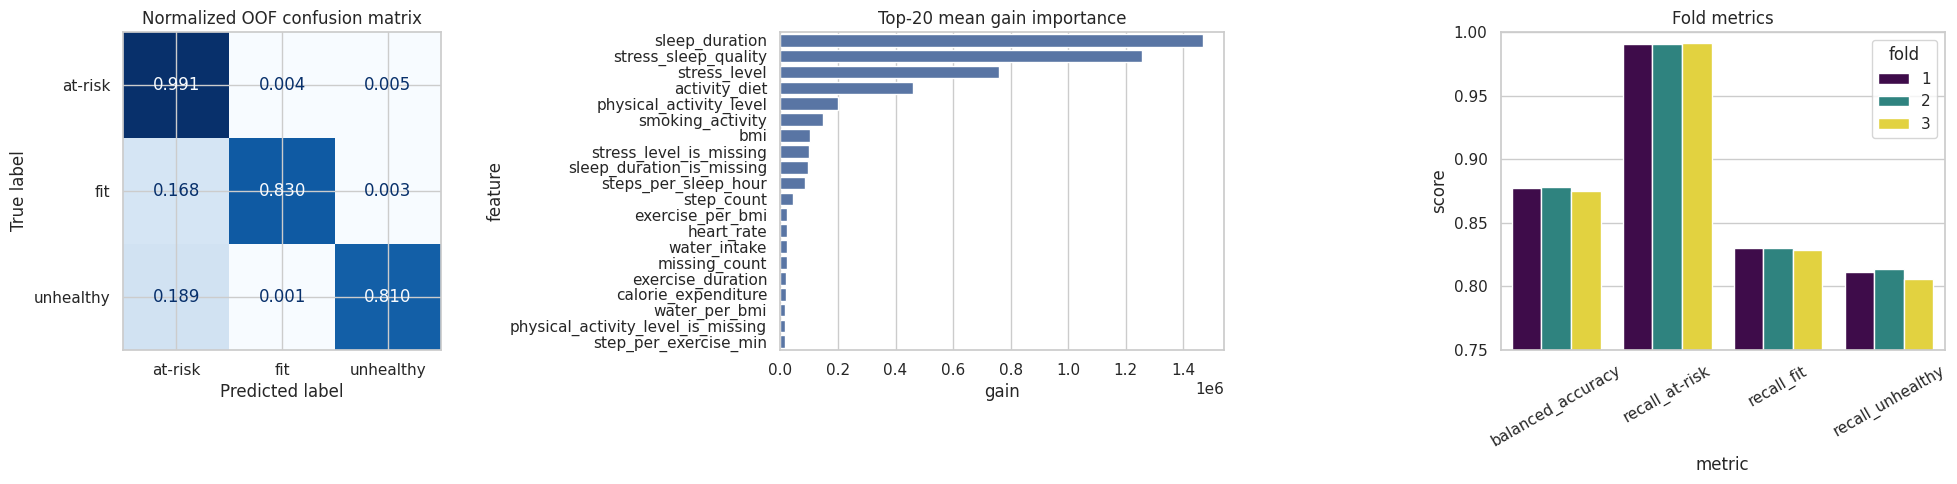

In [17]:
raw_pred = oof_proba.argmax(axis=1)
raw_report = pd.DataFrame(classification_report(y, raw_pred, target_names=CLASSES, output_dict=True, zero_division=0)).T
raw_cm = confusion_matrix(y, raw_pred, normalize="true")
print("Raw OOF balanced accuracy:", balanced_accuracy_score(y, raw_pred))
display(raw_report.style.format("{:.4f}"))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ConfusionMatrixDisplay(raw_cm, display_labels=CLASSES).plot(cmap="Blues", values_format=".3f", ax=axes[0], colorbar=False)
axes[0].set_title("Normalized OOF confusion matrix")

importance = (pd.concat(fold_importance).groupby("feature", as_index=False)["gain"].mean()
              .sort_values("gain", ascending=False).head(20))
sns.barplot(data=importance, y="feature", x="gain", ax=axes[1], color="#4C72B0")
axes[1].set_title("Top-20 mean gain importance")

metric_cols = ["balanced_accuracy"] + [f"recall_{label}" for label in CLASSES]
fold_long = fold_metrics.melt(id_vars="fold", value_vars=metric_cols, var_name="metric", value_name="score")
sns.barplot(data=fold_long, x="metric", y="score", hue="fold", ax=axes[2], palette="viridis")
axes[2].set_ylim(0.75, 1.0)
axes[2].set_title("Fold metrics")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

fold_metrics.to_csv("fold_metrics.csv", index=False)
importance.to_csv("feature_importance_top20.csv", index=False)

## 8. Validated Class-Multiplier Post-processing

,pipeline,balanced_accuracy,recall_at-risk,recall_fit,recall_unhealthy
0,raw_argmax,0.876950,0.991103,0.829686,0.810062
1,validated_multipliers,0.948480,0.942887,0.945255,0.957297


,precision,recall,f1-score,support
at-risk,0.9925,0.9429,0.9671,592561.0000
fit,0.7488,0.9453,0.8356,39803.0000
unhealthy,0.7186,0.9573,0.8209,57724.0000
accuracy,0.9442,0.9442,0.9442,0.9442
macro avg,0.8200,0.9485,0.8745,690088.0000
weighted avg,0.9555,0.9442,0.9473,690088.0000


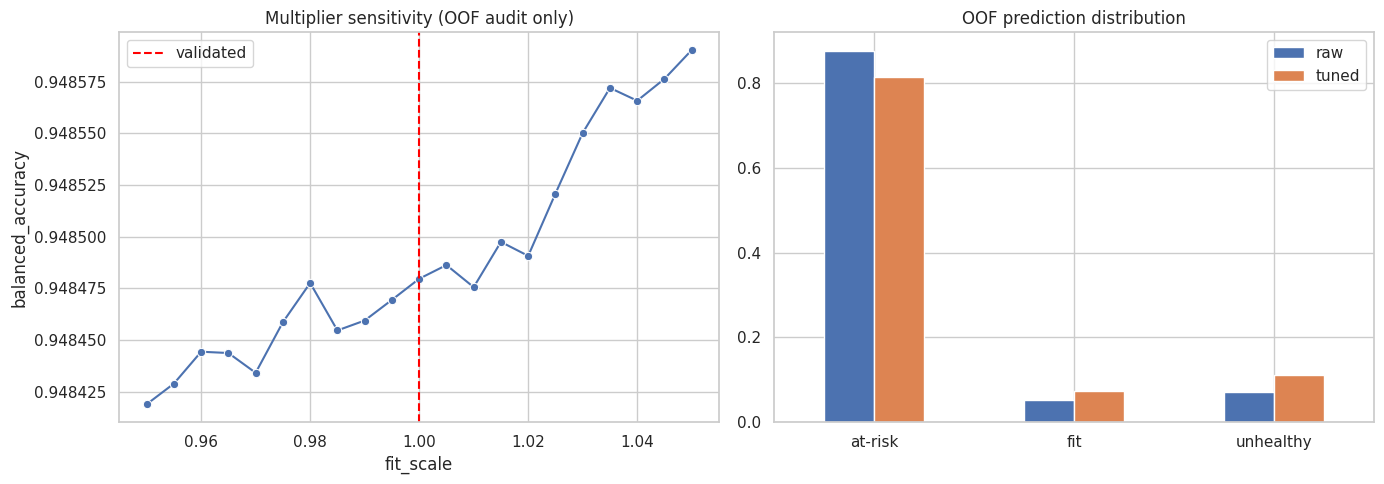

In [18]:
# OOF-selected and public-LB validated E002 multipliers; not retuned against public LB.
MULTIPLIERS = np.array([0.18922984217739805, 1.444453232368245, 1.3663169254543568])
tuned_pred = np.argmax(oof_proba * MULTIPLIERS, axis=1)
tuned_score = balanced_accuracy_score(y, tuned_pred)
tuned_report = pd.DataFrame(classification_report(y, tuned_pred, target_names=CLASSES, output_dict=True, zero_division=0)).T

comparison = pd.DataFrame({
    "pipeline": ["raw_argmax", "validated_multipliers"],
    "balanced_accuracy": [balanced_accuracy_score(y, raw_pred), tuned_score],
    **{f"recall_{label}": [raw_report.loc[label, "recall"], tuned_report.loc[label, "recall"]] for label in CLASSES},
})
display(comparison.style.format({c: "{:.6f}" for c in comparison if c != "pipeline"}))
display(tuned_report.style.format("{:.4f}"))

scales = np.linspace(0.95, 1.05, 21)
sensitivity = []
for fit_scale in scales:
    candidate = MULTIPLIERS * np.array([1.0, fit_scale, 1.0])
    sensitivity.append({"fit_scale": fit_scale, "balanced_accuracy": balanced_accuracy_score(y, np.argmax(oof_proba * candidate, axis=1))})
sensitivity = pd.DataFrame(sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=sensitivity, x="fit_scale", y="balanced_accuracy", marker="o", ax=axes[0])
axes[0].axvline(1.0, color="red", linestyle="--", label="validated")
axes[0].legend()
axes[0].set_title("Multiplier sensitivity (OOF audit only)")

distribution = pd.DataFrame({
    "raw": pd.Series(np.array(CLASSES)[raw_pred]).value_counts(normalize=True),
    "tuned": pd.Series(np.array(CLASSES)[tuned_pred]).value_counts(normalize=True),
}).reindex(CLASSES)
distribution.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("OOF prediction distribution")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 9. Create `submission.csv`

In [19]:
test_pred = np.argmax(test_proba * MULTIPLIERS, axis=1)
submission = sample_submission[[ID_COL]].copy()
submission[TARGET] = np.array(CLASSES)[test_pred]

assert submission.shape == sample_submission.shape
assert submission[ID_COL].equals(sample_submission[ID_COL])
assert submission[TARGET].isin(CLASSES).all()
assert submission[TARGET].notna().all()

submission_distribution = submission[TARGET].value_counts().reindex(CLASSES, fill_value=0)
expected_distribution = pd.Series({"at-risk": 241579, "fit": 21297, "unhealthy": 32877}, name="validated_E002")
distribution_check = pd.concat([submission_distribution.rename("current"), expected_distribution], axis=1)
distribution_check["difference"] = distribution_check["current"] - distribution_check["validated_E002"]
display(distribution_check)

# GPU implementations can have tiny floating-point differences; large label shifts require investigation.
assert distribution_check["difference"].abs().max() < 2_000, "Unexpected submission distribution shift"
submission.to_csv("submission.csv", index=False)
print("Saved: submission.csv", submission.shape)
display(submission.head())

,current,validated_E002,difference
at-risk,241598,241579,19
fit,21293,21297,-4
unhealthy,32862,32877,-15


Saved: submission.csv (295753, 2)


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
